## Dataset Construction and Forward Pass

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('../names.txt', 'r').read().splitlines()
print(words[:8])
print(len(words))

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
32033


In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s: i for i, s in enumerate(chars, start=1)}
stoi['.'] = 0 # use as start/end token
itos = {i: s for s, i in stoi.items()}
print(itos)
print(stoi)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [4]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []

for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', ch)
        context = context[1:] + [ix] # shifting the contex window

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [5]:
X.shape, X.dtype, Y.shape, Y.dtype 

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [6]:
C = torch.randn((27, 2))

In [7]:
# indexing is equivalent to use of one-hot encoding done in the first layer of neural network
print(C[5])
print(F.one_hot(torch.tensor(5), num_classes=27).float() @ C)

tensor([-1.1836, -1.7815])
tensor([-1.1836, -1.7815])


In [8]:
print(X[13, 2])
print(C[X][13, 2])
print(C[1])

tensor(1)
tensor([2.0771, 0.3881])
tensor([2.0771, 0.3881])


In [9]:
emb = C[X]

W1 = torch.randn(6, 100)
b1 = torch.randn(100)

emb = torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1)

print(emb.shape, W1.shape)
emb @ W1 + b1


torch.Size([32, 6]) torch.Size([6, 100])


tensor([[ 1.4401,  1.2000,  0.6036,  ...,  6.0455, -4.9276, -3.8409],
        [ 2.5662,  1.2661,  3.1567,  ...,  6.2263, -4.8253, -5.0308],
        [-0.5765,  1.9152, -0.4628,  ...,  4.9392, -3.9570, -0.9219],
        ...,
        [-0.9019,  1.3724, -2.8754,  ..., -0.1932,  3.2157,  3.3957],
        [ 0.2675,  0.6437,  0.4591,  ..., -0.4803,  4.5853,  1.4992],
        [-0.5934, -0.8127, -2.0019,  ..., -0.8900,  1.7612,  3.6478]])

- view() function is highly efficient. cat() or unbind() create the output tensor in a new memory place, whereas view() uses the same memory.  
- PyTorch keep the actual data as a 1D array (call .storage() from a tensor) as it in the actual computer memory.
- It keeps an internal parameters (storage offset, strides and shapes) to manipulate the data as if N-dimentional array during tensor operations. 
- For details about PyTorch internals, see [this post](https://blog.ezyang.com/2019/05/pytorch-internals/).

In [10]:
a = torch.arange(80)
print(a.shape)
a = a.view(16, 5, 1)
print(a.shape)
a = a.view(1, 2, 5, 4, 2)
print(a.shape)
a = a.view(-1, 16)
print(a.shape)

torch.Size([80])
torch.Size([16, 5, 1])
torch.Size([1, 2, 5, 4, 2])
torch.Size([5, 16])


In [11]:
a = torch.arange(12)
a.storage()

/var/folders/xh/jv4dsp5n13nf07dl_7dskp140000gn/T/ipykernel_2836/1393808857.py:2: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a.storage()


 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 12]

In [12]:
# always make sure that the broadcasting works as expected
print(b1.shape)
print((emb.view(-1, 6) @ W1).shape)
# Pytorch will act the bias with shape of (100) as shape of (32, 100)

torch.Size([100])
torch.Size([32, 100])


In [13]:
torch.tanh(emb.view(-1, 6) @ W1 + b1)

tensor([[ 0.8937,  0.8337,  0.5396,  ...,  1.0000, -0.9999, -0.9991],
        [ 0.9883,  0.8527,  0.9964,  ...,  1.0000, -0.9999, -0.9999],
        [-0.5201,  0.9575, -0.4323,  ...,  0.9999, -0.9993, -0.7268],
        ...,
        [-0.7172,  0.8792, -0.9937,  ..., -0.1909,  0.9968,  0.9978],
        [ 0.2613,  0.5674,  0.4293,  ..., -0.4465,  0.9998,  0.9050],
        [-0.5323, -0.6711, -0.9642,  ..., -0.7114,  0.9426,  0.9986]])

In [14]:
# define vocabulary (each character mapped to a 2D vector)
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)

# define a 2-layer MLP
W1 = torch.randn(6, 100, generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn(100, 27, generator=g)
b2 = torch.randn(27, generator=g)

# forward pass
emb = C[X].view(-1, 6)
h = torch.tanh(emb @ W1 + b1) # first layer
logits = h @ W2 + b2 # second layer: no activation, producing raw outputs (logits)

# calculate the loss
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
loss = -probs[torch.arange(Y.shape[0]), Y].log().mean() # Negative Log-Likelihood (NLL) loss
print('loss:', loss)

loss: tensor(17.7697)


In [15]:
# we don't need to reinvent the wheel.
F.cross_entropy(logits, Y)

tensor(17.7697)

In [16]:
# define vocabulary (each character mapped to a 2D vector)
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)

# define a 2-layer MLP
W1 = torch.randn(6, 100, generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn(100, 27, generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

for k in range(1, 11):
    # forward pass
    emb = C[X].view(-1, 6)
    h = torch.tanh(emb @ W1 + b1) # first layer
    logits = h @ W2 + b2 # second layer: no activation, producing raw outputs (logits)

    # calculate the loss
    loss = F.cross_entropy(logits, Y)
    print(k, loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data -= 0.1 * p.grad

1 17.76971435546875
2 13.656402587890625
3 11.298770904541016
4 9.452457427978516
5 7.984263896942139
6 6.891320705413818
7 6.100014686584473
8 5.452036380767822
9 4.898151874542236
10 4.414664268493652


In [17]:
# now we can train the network on full dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []

for w in words:
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', ch)
        context = context[1:] + [ix] # shifting the contex window

X = torch.tensor(X)
Y = torch.tensor(Y)

In [18]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [19]:
# define vocabulary (each character mapped to a 2D vector)
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)

# define a 2-layer MLP
W1 = torch.randn(6, 100, generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn(100, 27, generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

nparams = sum(p.nelement() for p in parameters)
print('number of parameters:', nparams)

number of parameters: 3481


In [20]:
for p in parameters:
    p.requires_grad = True

for k in range(1000):
    # minibatch construct (for faster convergence)
    # instead of taking slow exact steps, take quick, noisy but good enough steps
    ix = torch.randint(0, X.shape[0], (32, ))
    
    # forward pass
    emb = C[X[ix]].view(-1, 6)
    h = torch.tanh(emb @ W1 + b1) # first layer
    logits = h @ W2 + b2 # second layer: no activation, producing raw outputs (logits)

    # calculate the loss
    loss = F.cross_entropy(logits, Y[ix])
    print(k, loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data -= 0.1 * p.grad

0 23.208965301513672
1 16.89308738708496
2 16.135892868041992
3 14.627410888671875
4 15.6693115234375
5 12.618322372436523
6 12.411860466003418
7 12.813750267028809
8 9.134990692138672
9 13.425962448120117
10 12.859112739562988
11 11.563980102539062
12 8.579548835754395
13 10.965655326843262
14 9.493556022644043
15 7.663164138793945
16 6.647916316986084
17 8.144871711730957
18 9.09964370727539
19 9.959756851196289
20 7.083675384521484
21 9.68293285369873
22 8.858531951904297
23 9.245842933654785
24 7.216798782348633
25 9.404001235961914
26 8.99089241027832
27 6.9550652503967285
28 7.518472671508789
29 6.6798996925354
30 8.256299018859863
31 6.703307151794434
32 7.457809925079346
33 7.79702091217041
34 6.576949119567871
35 7.133492469787598
36 6.897759437561035
37 5.488061904907227
38 6.058538436889648
39 7.050776481628418
40 6.462242603302002
41 5.912478446960449
42 4.81537389755249
43 5.678510665893555
44 6.206099510192871
45 4.460267066955566
46 7.465590953826904
47 5.872827529907227

In [21]:
# how to pick a good learning rate?
lre = torch.linspace(-3, 0, 1000) # exponents
lrs = 10**lre

# start from a small learning rate to larger
lri = []
lossi = []

for p in parameters:
    p.requires_grad = True

for i in range(1000):
    # minibatch construct (for faster convergence)
    # instead of moving along the exact gradient direction 'slowly', 
    # move along noisy but good enough gradient direction 'guickly'.
    ix = torch.randint(0, X.shape[0], (32, ))
    
    # forward pass
    emb = C[X[ix]].view(-1, 6)
    h = torch.tanh(emb @ W1 + b1) # first layer
    logits = h @ W2 + b2 # second layer: no activation, producing raw outputs (logits)

    # calculate the loss
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = lrs[i]
    for p in parameters:
        p.data -= lr * p.grad

    # track stats
    lri.append(lre[i])
    lossi.append(loss.item())


2.4340903759002686
2.698007106781006
2.9696247577667236
3.147474765777588
2.5976719856262207
2.7117600440979004
3.144301176071167
2.7619166374206543
3.1212105751037598
2.4288225173950195
2.8454296588897705
2.5747365951538086
2.2045998573303223
2.5795998573303223
2.4124085903167725
2.340531587600708
2.844101667404175
2.6601152420043945
2.707674503326416
3.08779239654541
2.6866183280944824
2.816983461380005
2.7218806743621826
2.5490212440490723
2.662395715713501
2.9339559078216553
2.6170639991760254
2.736389636993408
2.7935147285461426
2.3726444244384766
2.541872262954712
2.5610809326171875
2.395763635635376
2.6248862743377686
2.6165215969085693
2.6696600914001465
2.910311698913574
2.651893377304077
2.6633832454681396
2.5919301509857178
2.644943952560425
2.531061887741089
2.683565378189087
2.5745723247528076
2.6113929748535156
2.5190494060516357
2.3634941577911377
2.930152177810669
2.978191375732422
2.3450121879577637
2.8671019077301025
2.6372649669647217
2.5063648223876953
2.85800409317

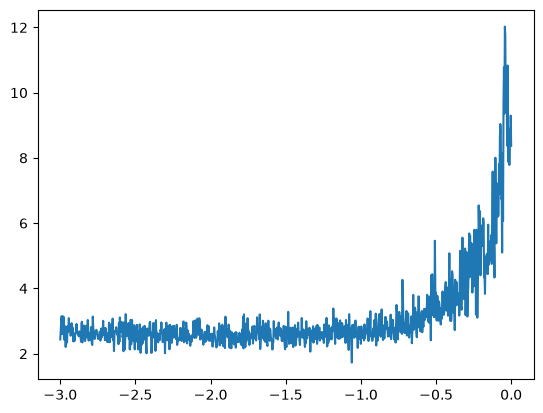

In [22]:
plt.plot(lri, lossi)

In [23]:
# so somewhere around -1.0 is a very good learning rate (0.1)

## Splitting the Dataset into train/val/test Splits

In [24]:
import random

def build_dataset(words, context_len=3):
    X, Y = [], []

    for w in words:
        context = [0] * context_len
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[x] for x in context), '-->', ch), 
            context = context[1:] + [ix]

    return torch.tensor(X), torch.tensor(Y)


random.seed(42)
random.shuffle(words)

n1, n2 = int(0.8 * len(words)), int(0.9 * len(words))

# train, val/dev, and test splits
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

print(Xtr.shape, Ytr.shape)
print(Xdev.shape, Ydev.shape)
print(Xte.shape, Yte.shape)

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [25]:
# define vocabulary (each character mapped to a 2D vector)
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)

# define a 2-layer MLP
W1 = torch.randn(6, 100, generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn(100, 27, generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

nparams = sum(p.nelement() for p in parameters)
print('number of parameters:', nparams)

number of parameters: 3481


2.858889579772949


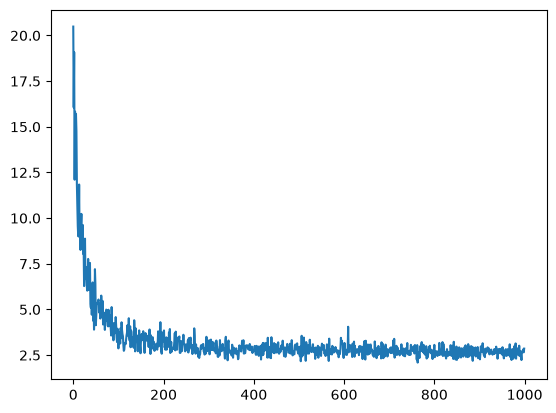

In [26]:
lr = 0.1 # we observed that this is a nice learning rate

stepi, lossi = [], []

for p in parameters:
    p.requires_grad = True

for i in range(1000):
    # minibatch construct (for faster convergence)
    # instead of moving along the exact gradient direction 'slowly', 
    # move along noisy but good enough gradient direction 'guickly'.
    ix = torch.randint(0, Xtr.shape[0], (32, ))
    
    # forward pass
    emb = C[Xtr[ix]].view(-1, 6)
    h = torch.tanh(emb @ W1 + b1) # first layer
    logits = h @ W2 + b2 # second layer: no activation, producing raw outputs (logits)

    # calculate the loss
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data -= lr * p.grad

    # keep track the stats
    lossi.append(loss.item())
    stepi.append(i)
    # print(loss.item())
    
print(loss.item())

plt.plot(stepi, lossi)

In [27]:
emb = C[Xtr].view(-1, 6)
h = torch.tanh(emb @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss.item()

2.693307399749756

In [28]:
emb = C[Xdev].view(-1, 6)
h = torch.tanh(emb @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss.item()

2.688952922821045

- Since the train and val losses are roughly equal. 
- This indicates that the network is not powerful enough to just memorize the training data (overfitting).
- However the loss is high, the model is underfitting.

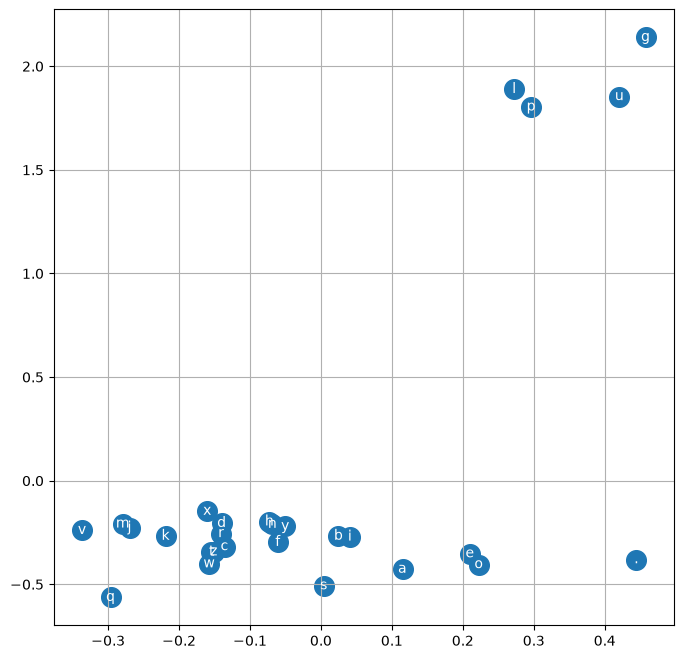

In [29]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

## Increasing Model Capacity

In [30]:
# let's increase the dimension of char vectors from 2 to 10
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)

# define a 2-layer MLP
W1 = torch.randn(30, 200, generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn(200, 27, generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

nparams = sum(p.nelement() for p in parameters)
print('number of parameters:', nparams)

for p in parameters:
    p.requires_grad = True

number of parameters: 11897


2.353224277496338


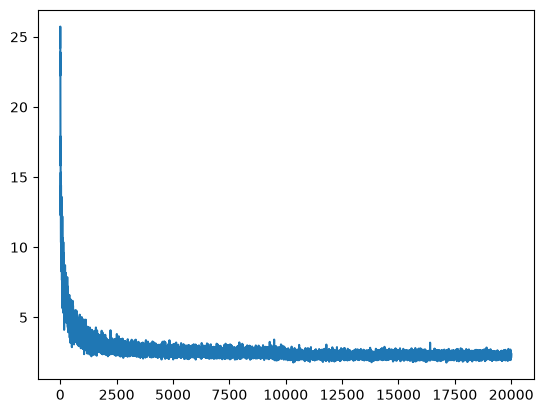

In [31]:
stepi, lossi = [], []

for i in range(20000):
    # minibatch construct (for faster convergence)
    # instead of moving along the exact gradient direction 'slowly', 
    # move along noisy but good enough gradient direction 'guickly'.
    ix = torch.randint(0, Xtr.shape[0], (64, )) # increase batch size
    
    # forward pass
    emb = C[Xtr[ix]].view(-1, 30)
    h = torch.tanh(emb @ W1 + b1) # first layer
    logits = h @ W2 + b2 # second layer: no activation, producing raw outputs (logits)

    # calculate the loss
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 10000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

    # keep track the stats
    lossi.append(loss.item())
    stepi.append(i)
    # print(loss.item())
    
print(loss.item())

plt.plot(stepi, lossi)

In [32]:
emb = C[Xdev].view(-1, 30)
h = torch.tanh(emb @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss.item()

2.298516273498535

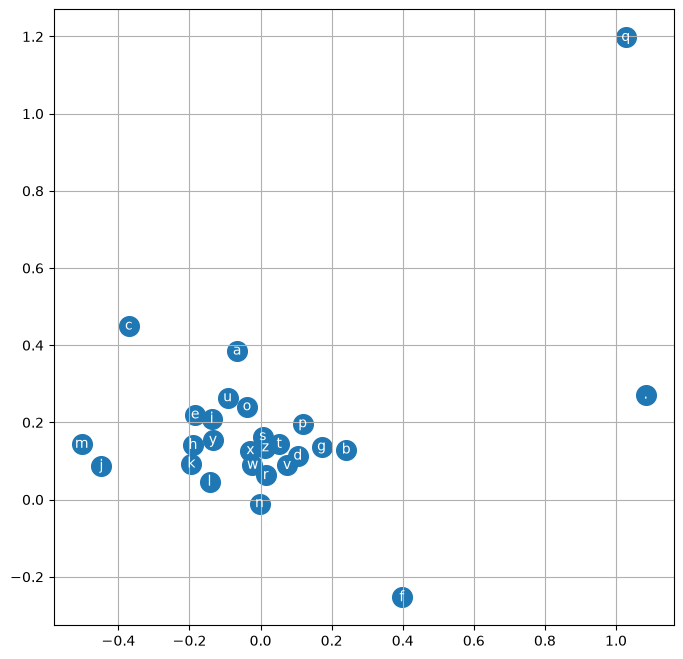

In [33]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

In [45]:
# sampling from the trained model
g = torch.Generator().manual_seed(2147483647)

for i in range(20):
    out = []
    context = [0] * block_size

    while True:
        emb = C[context].view(1, 30)
        h = torch.tanh(emb @ W1 + b1)
        logits = h @ W2 + b2
        # counts = logits.exp()
        # probs = counts / counts.sum(1, keepdim=True)
        probs = torch.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        if ix == 0:
            break
        out.append(itos[ix])
        context = context[1:] + [ix]

    print(''.join(out))


cerze
lomanuraile
kayha
konimitta
nella
kaki
ar
samiyaulytthi
gotos
molie
cavo
keyten
gea
emia
sadeu
tiaviyn
hatlse
hulingavtahlas
kasdr
breenley
